# Building a Nueral Network using the MNIST dataset.

Finn Farrell
03/05/2025

To begin I started by defining all of the imports from my previously created python enviroment. These will allow me to create, train and test my Nueral Network.

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import random
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image
from tensorflow.keras.datasets import mnist


Next, I loaded in the data set into  4 data structures, x_train, y_train, x_test and y_test so that I can test and train the model. It is then normalized by 225 to provide a 0-1 gradient value which will be used for detecting the numeric strokes when training the model. Normalizing ensures that all inputs to the Nueral Network are of the same scale. This is important for the learning proccess since it simplifies the work to be done by the module during training.

In [2]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize the data (scale to 0-1)
x_train, x_test = x_train / 255.0, x_test / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


To build the network, I defined a sequential model that takes a 28x28 image, feature 128 hidden layers and uses SoftMax to output and claddify each entity as a digit from 0-9. Sequential models are typical for these types of classification problems that feature linear stacks of layers that build upon eachother.
The Dropout helps prevent overfitting by randomly dropping a fraction (0.2 in my case) of neurons during the training proccess. This effectively prevents the network from over-relying on specific neurons, forcing it to learn more robust and generalized features.
The SoftMax algorithm then spits out our values and determines which output cluster they should be a part of. 

In [3]:
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),      # Flatten 28x28 images to 784
    layers.Dense(128, activation='relu'),      # Hidden layer with 128 neurons
    layers.Dropout(0.2),                       # Dropout for regularization
    layers.Dense(10, activation='softmax')     # Output: 10 classes (digits 0-9)
])

c:\Users\finnf\anaconda3\envs\nnenv\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


I compliled the model using the Adam optimizer, which combines two other techniques Momentum and RMSprop which will adjust the learnign rates of the models params during training. Adam is a good choice since it is memory efficient, espeally for large data sets and it dynamically adjusts the params during training.
The errors are measured with 'sparse_categorical_crossentropy' which measures the difference between the labeled data and what the model predicts. This will then be taken into account when adjusting the weights of the layers.
Metrics tracks the performance of the model, with accuracy showing the correctness of the models predictions.

In [4]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


It was now time to train the model! I waned to ensure as much accuracy as possible (and harm my cpu) so I decided to train over 20 epochs. The model begins with an accuracy of 85% after epoch 1 and then improves until it reaches 99% accuracy after epoch 20. As accuracy increases, the models loss decreases.

In [5]:
model.fit(x_train, y_train, epochs=20)


Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8598 - loss: 0.4864
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9550 - loss: 0.1528
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9672 - loss: 0.1090
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9730 - loss: 0.0860
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9784 - loss: 0.0722
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9800 - loss: 0.0638
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9823 - loss: 0.0557
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9822 - loss: 0.0546
Epoch 9/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.9849 - loss: 0.0451
Epoch 10/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9858 - loss: 0.0432
Epoch 11/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9874 - loss: 0.0368
Epoch 12/20
1875/1875 ━━━━━━

Finally I wanted to test the accuracy of the model. It evaluates with a final accuracy of 98%, which is almost perfect for a number predicting Nueral Network.

In [6]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9762 - loss: 0.1020
Test accuracy: 0.9805999994277954


To demonstrate the model correctly predicting the number, I chose a random piece of data and matched it to the number that the model thought it would be.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 569us/step
Random index chosen: 9729
Predicted number: 6
True label: 5


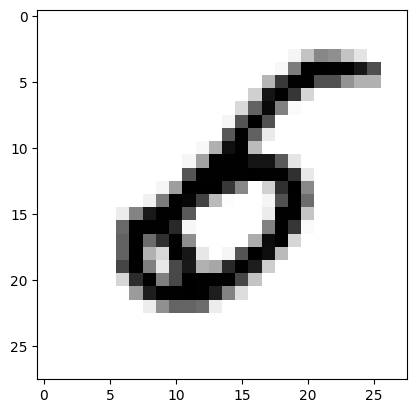

In [38]:
predictions = model.predict(x_test)
random_index = random.randint(0, len(x_test) - 1)

predicted_array = predictions[random_index]
predicted_number = np.argmax(predicted_array)

print("Random index chosen:", random_index)
print("Predicted number:", predicted_number)
print("True label:", y_test[random_index])

plt.imshow(x_test[random_index], cmap=plt.cm.binary)
plt.show()

To gather a set of images with a specific lab, I found the numbers that had tested to 3 and returned true. I then plotted a number of these in a 5x5 grid to give an idea of how well the model could predict letters of different handwriting styles correclty.

Number of images with label 3: 1010


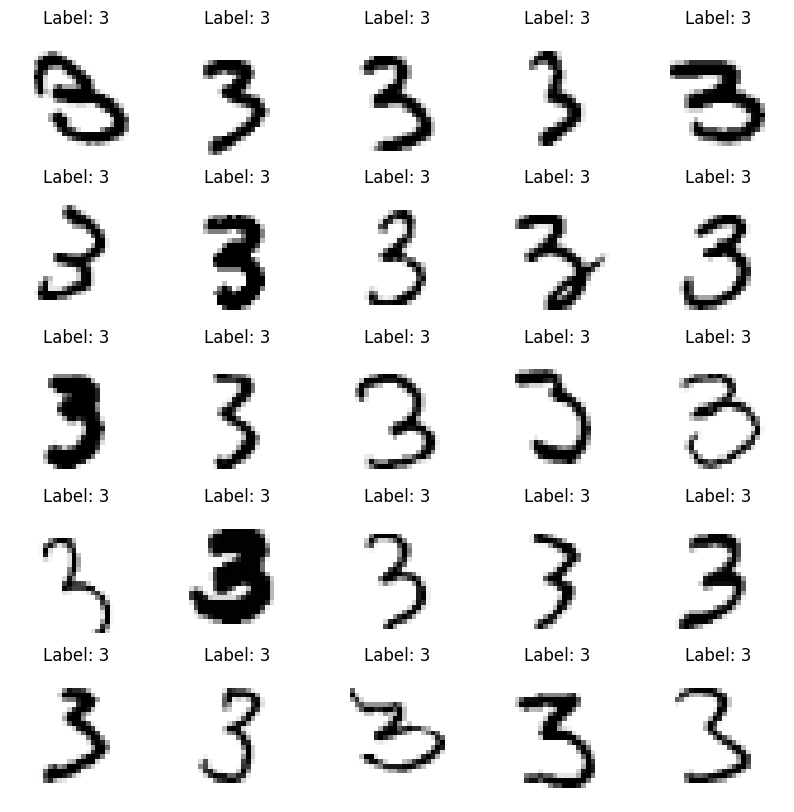

In [ ]:
indices_of_3 = np.where(y_test == 3)[0]

print(f"Number of images with label 3: {len(indices_of_3)}")

plt.figure(figsize=(10, 10))

for i, idx in enumerate(indices_of_3):
    plt.subplot(5, 5, i + 1) 
    plt.imshow(x_test[idx], cmap=plt.cm.binary)
    plt.title(f"Label: {y_test[idx]}")
    plt.axis('off')
    
    if i == 24:
        break

plt.show()

Finally I wanted to see whther the model could predict my own handwriting. To do this I created a 28x28 png using Paint and loaded it into my model. The code ensures that it is 28x28 and in the suitable greyscale model. It then normalises it so that it can be proccessed. 

In [44]:

img = image.load_img('test.png', color_mode='grayscale', target_size=(28, 28))
img_array = image.img_to_array(img)

img_array = 255 - img_array
img_array = img_array / 255.0
img_array = img_array.reshape(1, 28, 28)

prediction = model.predict(img_array)
predicted_number = np.argmax(prediction)

print("Predicted number:", predicted_number)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Predicted number: 6
